In [2]:
import tensorflow as tf
import numpy as np

I0000 00:00:1776128783.110048    8274 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776128783.392214    8274 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776128784.603823    8274 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
data = np.loadtxt('stock_price_curated.csv', delimiter=',')

data = data.T
np.random.shuffle(data)
data = data.T

X = data[:253,:]
Y = data[-1:,:]

change_mean = np.mean(X[252,:])
change_std = np.std(X[252,:])

X[252,:] = (X[252,:] - change_mean) / change_std

print(np.mean(X[252,:]))
print(np.std(X[252,:]))

print(X.shape)
print(Y.shape)

print(np.mean(Y))
print(np.std(Y))

-9.936725230149182e-18
1.0
(253, 74367)
(1, 74367)
2.739996263790355
8.066457063860991


In [8]:
print(X[252,0])
print(Y[0,0])

-1.0616154829533067
-0.8430119561709629


In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(253, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8), input_shape=(253,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(1e-8)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='linear'),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(delta=0.5),
    metrics=['mae']
)

model.summary()


E0000 00:00:1776128859.126234    8274 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/aus/Code/school/3ML3-Final/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,076 (765.92 KB)

 Trainable params: 194,558 (759.99 KB)

 Non-trainable params: 1,518 (5.93 KB)

In [10]:
# Clip extreme outliers in Y so MSE isn't dominated by rare spikes
# (p99 ≈ 2.09, but max ≈ 19 — those few outliers monopolize the gradient)
y_lo = np.percentile(Y, 1)
y_hi = np.percentile(Y, 99)
print(f"Clipping Y to [{y_lo:.4f}, {y_hi:.4f}]  (was [{Y.min():.4f}, {Y.max():.4f}])")
Y = np.clip(Y, y_lo, y_hi)

Clipping Y to [-6.3218, 17.1209]  (was [-27.7037, 1362.0183])


In [11]:
train_ratio = 0.8
train_size = int(X.shape[1] * train_ratio)

X_train = X[:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,train_size:].T
Y_val = Y[:,train_size:].T

print(X_train.shape)
print(X_val.shape)

(59493, 253)
(14874, 253)


In [12]:
# Normalize features
#mean = X_train.mean(axis=0)
#std  = X_train.std(axis=0) + 1e-8
#X_train = (X_train - mean) / std
#X_val   = (X_val   - mean) / std

# Normalize Y — without this the output layer fights a non-zero offset
# and the model collapses to predicting the mean/median
y_mean = Y_train.mean()
y_std  = Y_train.std() + 1e-8
Y_train_norm = (Y_train - y_mean) / y_std
Y_val_norm   = (Y_val   - y_mean) / y_std
print(f"Y normalized: mean→0, std→1  (y_mean={y_mean:.4f}, y_std={y_std:.4f})")


Y normalized: mean→0, std→1  (y_mean=2.6236, y_std=4.0784)


In [73]:
model.fit(X_train, Y_train_norm,
                  validation_data=(X_val, Y_val_norm),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)


Epoch 1/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2936 - mae: 0.8008 - val_loss: 0.2427 - val_mae: 0.6927
Epoch 2/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2463 - mae: 0.7004 - val_loss: 0.2428 - val_mae: 0.6928
Epoch 3/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2439 - mae: 0.6947 - val_loss: 0.2396 - val_mae: 0.6856
Epoch 4/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2435 - mae: 0.6939 - val_loss: 0.2396 - val_mae: 0.6856
Epoch 5/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2434 - mae: 0.6939 - val_loss: 0.2422 - val_mae: 0.6915
Epoch 6/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2430 - mae: 0.6930 - val_loss: 0.2407 - val_mae: 0.6884
Epoch 7/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2425 - mae: 0.6918 - val_loss: 0.2401 - val_mae: 0.6866
Epoch 8/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2430 - mae: 0.6925 - val_loss: 0.2391 - val_mae: 0.6846
Epoch 9/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [16]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation MAE for " + title)
    xs = list(range(1, len(history.history['mae']) + 1))
    plt.plot(xs, history.history['mae'], label="Model MAE", color="Red")
    plt.plot(xs, history.history['val_mae'], label="Validation MAE", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red")
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

def prcnt_within_tolerance(x, y, model, tolerance):
    return np.count_nonzero(abs(model.predict(x) - y) <= tolerance) / x.shape[0]

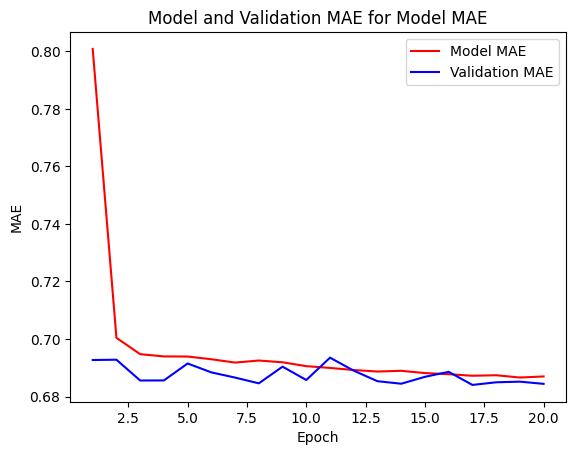

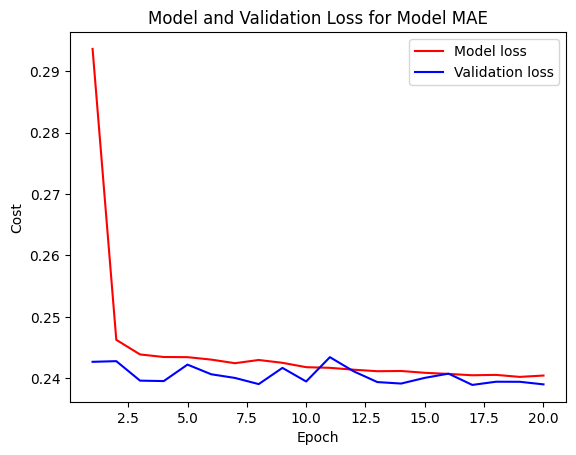

In [75]:
plot_acc_and_loss(model.history, "Model MAE")

In [78]:
print("Prediction:", model.predict(X_val[:10]) * y_std + y_mean)
print("Label:", Y_val[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prediction: [[-0.02299351]
 [ 4.411579  ]
 [ 2.74124403]
 [ 2.75427816]
 [ 0.44134201]
 [ 0.36552949]
 [ 0.71830885]
 [ 1.29428104]
 [ 3.20001373]
 [-0.07985398]]
Label: [[-4.83536104]
 [16.96182275]
 [ 0.44783814]
 [ 3.3049644 ]
 [ 2.52492652]
 [-4.2091254 ]
 [11.78985563]
 [-2.19318688]
 [ 1.32665355]
 [-1.4943423 ]]


In [22]:
modelMSE = tf.keras.Sequential([
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(253,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(126, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelMSE.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelMSE.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 126)            │        32,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,953 (890.44 KB)

 Trainable params: 226,435 (884.51 KB)

 Non-trainable params: 1,518 (5.93 KB)

In [28]:
modelMSE.fit(X_train, Y_train_norm,
                  validation_data=(X_val, Y_val_norm),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)

Epoch 1/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8936 - mae: 0.6940 - val_loss: 0.8932 - val_mae: 0.6909
Epoch 2/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8914 - mae: 0.6929 - val_loss: 0.9037 - val_mae: 0.6999
Epoch 3/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8919 - mae: 0.6933 - val_loss: 0.9004 - val_mae: 0.6995
Epoch 4/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8899 - mae: 0.6921 - val_loss: 0.8934 - val_mae: 0.6939
Epoch 5/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8885 - mae: 0.6918 - val_loss: 0.8984 - val_mae: 0.6935
Epoch 6/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8875 - mae: 0.6919 - val_loss: 0.8936 - val_mae: 0.6906
Epoch 7/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8874 - mae: 0.6920 - val_loss: 0.8967 - val_mae: 0.6909
Epoch 8/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8852 - mae: 0.6902 - val_loss: 0.8966 - val_mae: 0.6862
Epoch 9/20
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

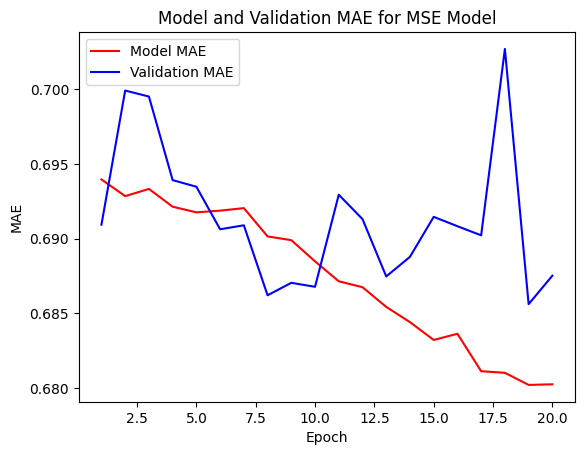

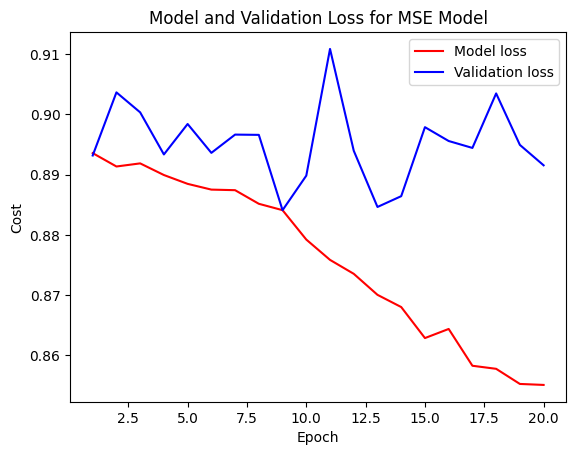

In [29]:
plot_acc_and_loss(modelMSE.history, "MSE Model")

In [55]:
print("Prediction:", modelMSE.predict(X_val[:15]) * y_std + y_mean)
print("Label:", Y_val[:15])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Prediction: [[-0.04728909]
 [ 6.81410272]
 [ 3.08320565]
 [ 2.74784324]
 [-0.32010244]
 [ 0.91389346]
 [-0.06806431]
 [ 1.17517497]
 [ 3.08916929]
 [-0.36276073]
 [ 1.63321005]
 [ 3.13876688]
 [ 2.70085577]
 [ 3.50859318]
 [ 3.16877996]]
Label: [[-4.83536104]
 [16.96253403]
 [ 0.44783814]
 [ 3.3049644 ]
 [ 2.52492652]
 [-4.2091254 ]
 [11.78985563]
 [-2.19318688]
 [ 1.32665355]
 [-1.4943423 ]
 [12.38519562]
 [ 1.977531  ]
 [ 0.77238416]
 [ 6.09690264]
 [ 8.89824799]]


In [58]:
print("Hubard Within 5%:", prcnt_within_tolerance(X_val, Y_val_norm, model, 0.05))
print("Hubard Within 10%:", prcnt_within_tolerance(X_val, Y_val_norm, model, 0.1))
print("Hubard Within 10%:", prcnt_within_tolerance(X_val, Y_val_norm, model, 0.2))

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step


ValueError: operands could not be broadcast together with shapes (14864,253,1) (14864,1) 

In [27]:
print("MSE Within 0.125(Avg is 0.0987):", prcnt_within_tolerance(X_val, Y_val_norm, modelMSE, 0.125))
print("MSE Within 0.25 (Avg is 0.1974):", prcnt_within_tolerance(X_val, Y_val_norm, modelMSE, 0.25))
print("MSE Within 0.5 (Avg is 0.383):", prcnt_within_tolerance(X_val, Y_val_norm, modelMSE, 0.5))
print("MSE Within 1 (Avg is 0.68):", prcnt_within_tolerance(X_val, Y_val_norm, modelMSE, 1))

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
MSE Within 0.125(Avg is 0.0987): 0.1302475780409042
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step
MSE Within 0.25 (Avg is 0.1974): 0.25518030139935416
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step
MSE Within 0.5 (Avg is 0.383): 0.47793326157158234
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step
MSE Within 1 (Avg is 0.68): 0.7721340150699677


In [37]:
modelWD = tf.keras.Sequential([
    tf.keras.layers.Dense(1000, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(500, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelWD.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelWD.summary()

/home/aus/Code/school/3ML3-Final/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 1000)           │       253,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 760,001 (2.90 MB)

 Trainable params: 757,001 (2.89 MB)

 Non-trainable params: 3,000 (11.72 KB)

In [38]:
modelWD.fit(X_train, Y_train_norm,
                  validation_data=(X_val, Y_val_norm),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)

Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 1.4231 - mae: 0.8702 - val_loss: 0.9556 - val_mae: 0.7300
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.9462 - mae: 0.7233 - val_loss: 0.8993 - val_mae: 0.7015
Epoch 3/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9118 - mae: 0.7073 - val_loss: 0.8834 - val_mae: 0.6944
Epoch 4/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.9051 - mae: 0.7035 - val_loss: 0.8830 - val_mae: 0.6947
Epoch 5/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9021 - mae: 0.7017 - val_loss: 0.9015 - val_mae: 0.7018
Epoch 6/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.9019 - mae: 0.7009 - val_loss: 0.8902 - val_mae: 0.6926
Epoch 7/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.8986 - mae: 0.6989 - val_loss: 0.9448 - val_mae: 0.7252
Epoch 8/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.8949 - mae: 0.6965 - val_loss: 0.9048 - val_mae: 0.6976
Epoch 9/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - lo

In [40]:
print("WD Within 0.125(Avg is 0.0987):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 0.125))
print("WD Within 0.25 (Avg is 0.1974):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 0.25))
print("WD Within 0.5 (Avg is 0.383):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 0.5))
print("WD Within 1 (Avg is 0.68):", prcnt_within_tolerance(X_val, Y_val_norm, modelWD, 1))

465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step
WD Within 0.125(Avg is 0.0987): 0.13121806937348748
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step
WD Within 0.25 (Avg is 0.1974): 0.2556466792148427
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step
WD Within 0.5 (Avg is 0.383): 0.4812449583221296
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step
WD Within 1 (Avg is 0.68): 0.771645603656897


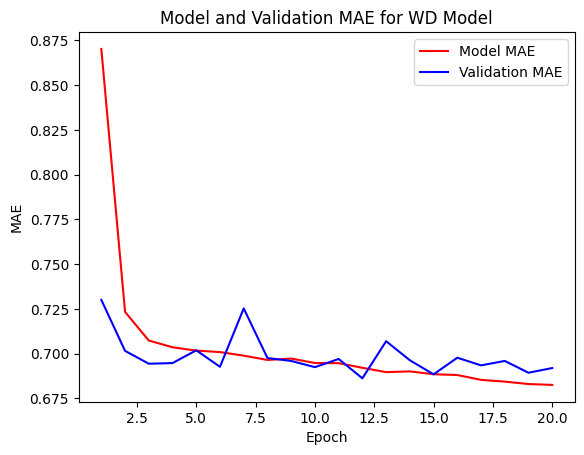

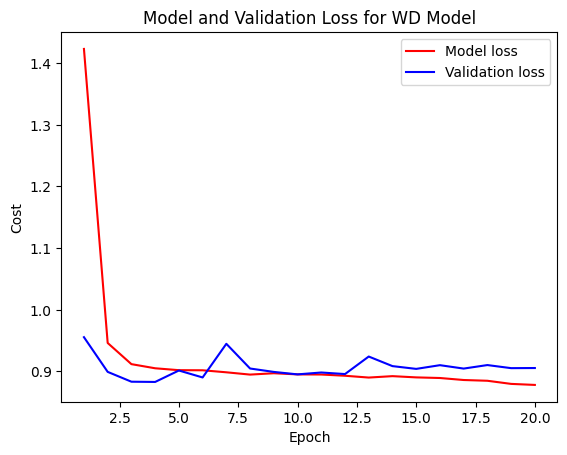

In [41]:
plot_acc_and_loss(modelWD.history, "WD Model")

In [42]:
modelLSTM = tf.keras.Sequential([
    tf.keras.layers.Dense(252, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(252,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Reshape((252, 1)),
    tf.keras.layers.LSTM(252),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelLSTM.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mae']
)

modelLSTM.summary()

/home/aus/Code/school/3ML3-Final/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 252)            │        63,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 252)            │         1,008 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 252, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 252)            │       256,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           253 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,049 (1.22 MB)

 Trainable params: 320,545 (1.22 MB)

 Non-trainable params: 504 (1.97 KB)

In [43]:
modelLSTM.fit(X_train, Y_train_norm,
                  validation_data=(X_val, Y_val_norm),
                  batch_size=64, 
                  epochs=20,
                  verbose=1,
                  shuffle=True)

Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 116s 123ms/step - loss: 0.8945 - mae: 0.7013 - val_loss: 0.8848 - val_mae: 0.6992
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 113s 122ms/step - loss: 0.8796 - mae: 0.6944 - val_loss: 0.8795 - val_mae: 0.6968
Epoch 3/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 113s 122ms/step - loss: 0.8748 - mae: 0.6933 - val_loss: 0.8731 - val_mae: 0.6902
Epoch 4/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 113s 122ms/step - loss: 0.8713 - mae: 0.6909 - val_loss: 0.8743 - val_mae: 0.6928
Epoch 5/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 113s 122ms/step - loss: 0.8670 - mae: 0.6892 - val_loss: 0.8797 - val_mae: 0.6962
Epoch 6/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 114s 122ms/step - loss: 0.8661 - mae: 0.6892 - val_loss: 0.8728 - val_mae: 0.6920
Epoch 7/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 114s 122ms/step - loss: 0.8635 - mae: 0.6881 - val_loss: 0.8713 - val_mae: 0.6912
Epoch 8/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 114s 122ms/step - loss: 0.8606 - mae: 0.6865 - val_loss: 0.8697 - val_mae: 0.6922
Epoch 9/20
930/930 ━━━━━

In [44]:
print("LSTM Within 0.125(Avg is 0.0987):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 0.125))
print("LSTM Within 0.25 (Avg is 0.1974):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 0.25))
print("LSTM Within 0.5 (Avg is 0.383):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 0.5))
print("LSTM Within 1 (Avg is 0.68):", prcnt_within_tolerance(X_val, Y_val_norm, modelLSTM, 1))

465/465 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step
LSTM Within 0.125(Avg is 0.0987): 0.13404140898090885
465/465 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step
LSTM Within 0.25 (Avg is 0.1974): 0.25867168593707984
465/465 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step
LSTM Within 0.5 (Avg is 0.383): 0.48339607421349823
465/465 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step
LSTM Within 1 (Avg is 0.68): 0.7739311642914762


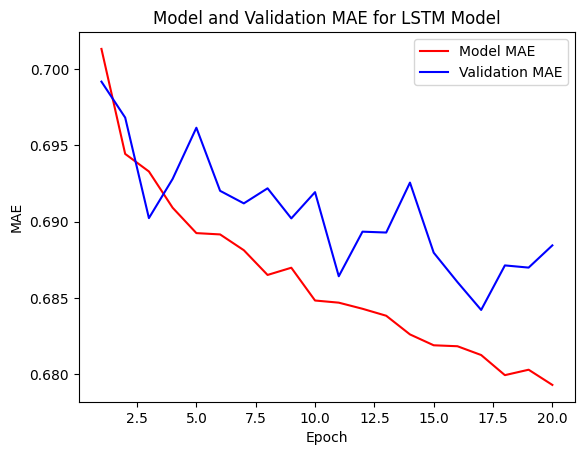

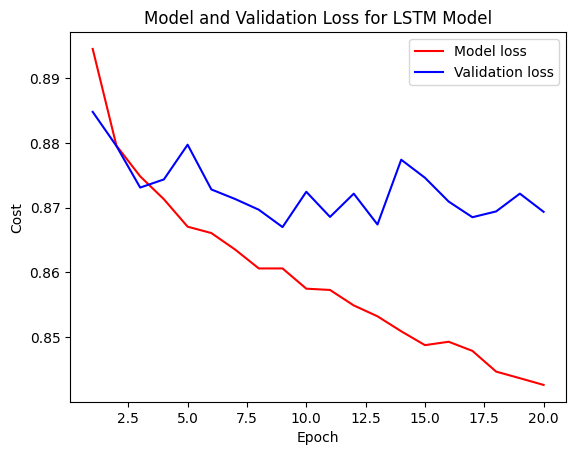

In [45]:
plot_acc_and_loss(modelLSTM.history, "LSTM Model")

In [13]:
def mean_quadratic_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    squared_error = tf.square(y_pred - y_true)
    return tf.reduce_mean(squared_error, axis=-1)


modelMQE = tf.keras.Sequential([
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5), input_shape=(253,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(253, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(126, activation='tanh', kernel_initializer="glorot_uniform", kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    tf.keras.layers.Dense(1, activation='linear'),
])

modelMQE.compile(
    optimizer='adam',
    loss=mean_quadratic_error,
    metrics=['mae']
)

modelMQE.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 253)            │         1,012 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 126)            │        32,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,953 (890.44 KB)

 Trainable params: 226,435 (884.51 KB)

 Non-trainable params: 1,518 (5.93 KB)

In [14]:
historyMQE = modelMQE.fit(
    X_train,
    Y_train_norm,
    validation_data=(X_val, Y_val_norm),
    batch_size=64,
    epochs=20,
    verbose=1,
    shuffle=True,
)

Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9527 - mae: 0.7240 - val_loss: 0.8806 - val_mae: 0.6967
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9103 - mae: 0.7052 - val_loss: 0.8800 - val_mae: 0.6973
Epoch 3/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9032 - mae: 0.7019 - val_loss: 0.8722 - val_mae: 0.6883
Epoch 4/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9044 - mae: 0.7029 - val_loss: 0.8582 - val_mae: 0.6863
Epoch 5/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9051 - mae: 0.7020 - val_loss: 0.8807 - val_mae: 0.6947
Epoch 6/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9044 - mae: 0.7018 - val_loss: 0.8657 - val_mae: 0.6844
Epoch 7/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9005 - mae: 0.7002 - val_loss: 0.8622 - val_mae: 0.6873
Epoch 8/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9018 - mae: 0.6993 - val_loss: 0.8693 - val_mae: 0.6911
Epoch 9/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

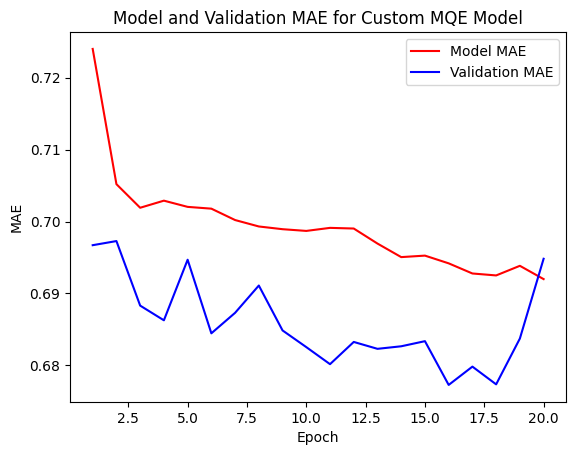

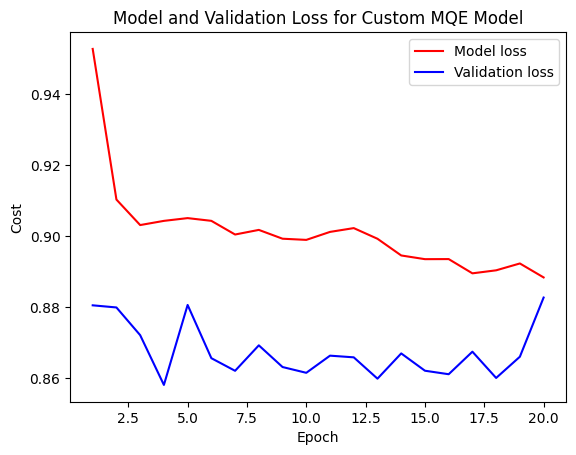

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Prediction: [[ 3.91439092]
 [ 3.71866082]
 [ 3.34983207]
 [ 4.56619999]
 [ 4.44290001]
 [ 2.99993336]
 [ 0.52780597]
 [ 0.41469397]
 [ 4.6175672 ]
 [ 0.6052145 ]
 [ 1.73759   ]
 [ 4.41464389]
 [-0.17508382]
 [ 5.31254108]
 [ 4.35749973]]
Label: [[ 8.04128095]
 [ 1.79040198]
 [ 4.46257892]
 [ 1.39555646]
 [-0.36976162]
 [-2.65246007]
 [-1.66640963]
 [ 4.28147998]
 [ 2.67257643]
 [ 1.92165157]
 [-0.55603196]
 [12.66887849]
 [-6.32184591]
 [-2.61792786]
 [ 3.34381146]]


In [17]:
plot_acc_and_loss(historyMQE, "Custom MQE Model")

print("Prediction:", modelMQE.predict(X_val[:15]) * y_std + y_mean)
print("Label:", Y_val[:15])